In [7]:
import stim
import numpy as np

from spiderwarp.csscode import CSSCode
from spiderwarp.utils import load_state_prep_circuit
from spiderwarp.stim_utils import steane_se_from_stim_state_prep, get_num_measurements, perfect_state_from_code, \
    get_circuit_depth
from spiderwarp.path_cover import CoveredZXGraph
from spiderwarp.path_cover_metrics import metric_spacetime_volume_exact, metric_hardware_qubits_exact, metric_num_paths
from spiderwarp.qubit_reuse import build_circuit_dag, apply_logical_qubit_merge_and_compress, dag_to_circuit, inject_qubit_reuse, VolumeOptimizingReuseStrategy, AggressiveDepthAwareStrategy


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
code_dir, code_name, circ_dir, circ_path = "misc", "32_20_4", "misc", "zero_32_20_4"
code = CSSCode.load_code(code_dir, code_name)

perfect_state = perfect_state_from_code(code, "X")

test = perfect_state.copy()
test.append("MX", range(code.n))
print(test.compile_sampler().sample(10)[:,-code.n:] @ code.H_x.T % 2)

[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]


Depth 60
Number of ancilla qubits necessary: 34


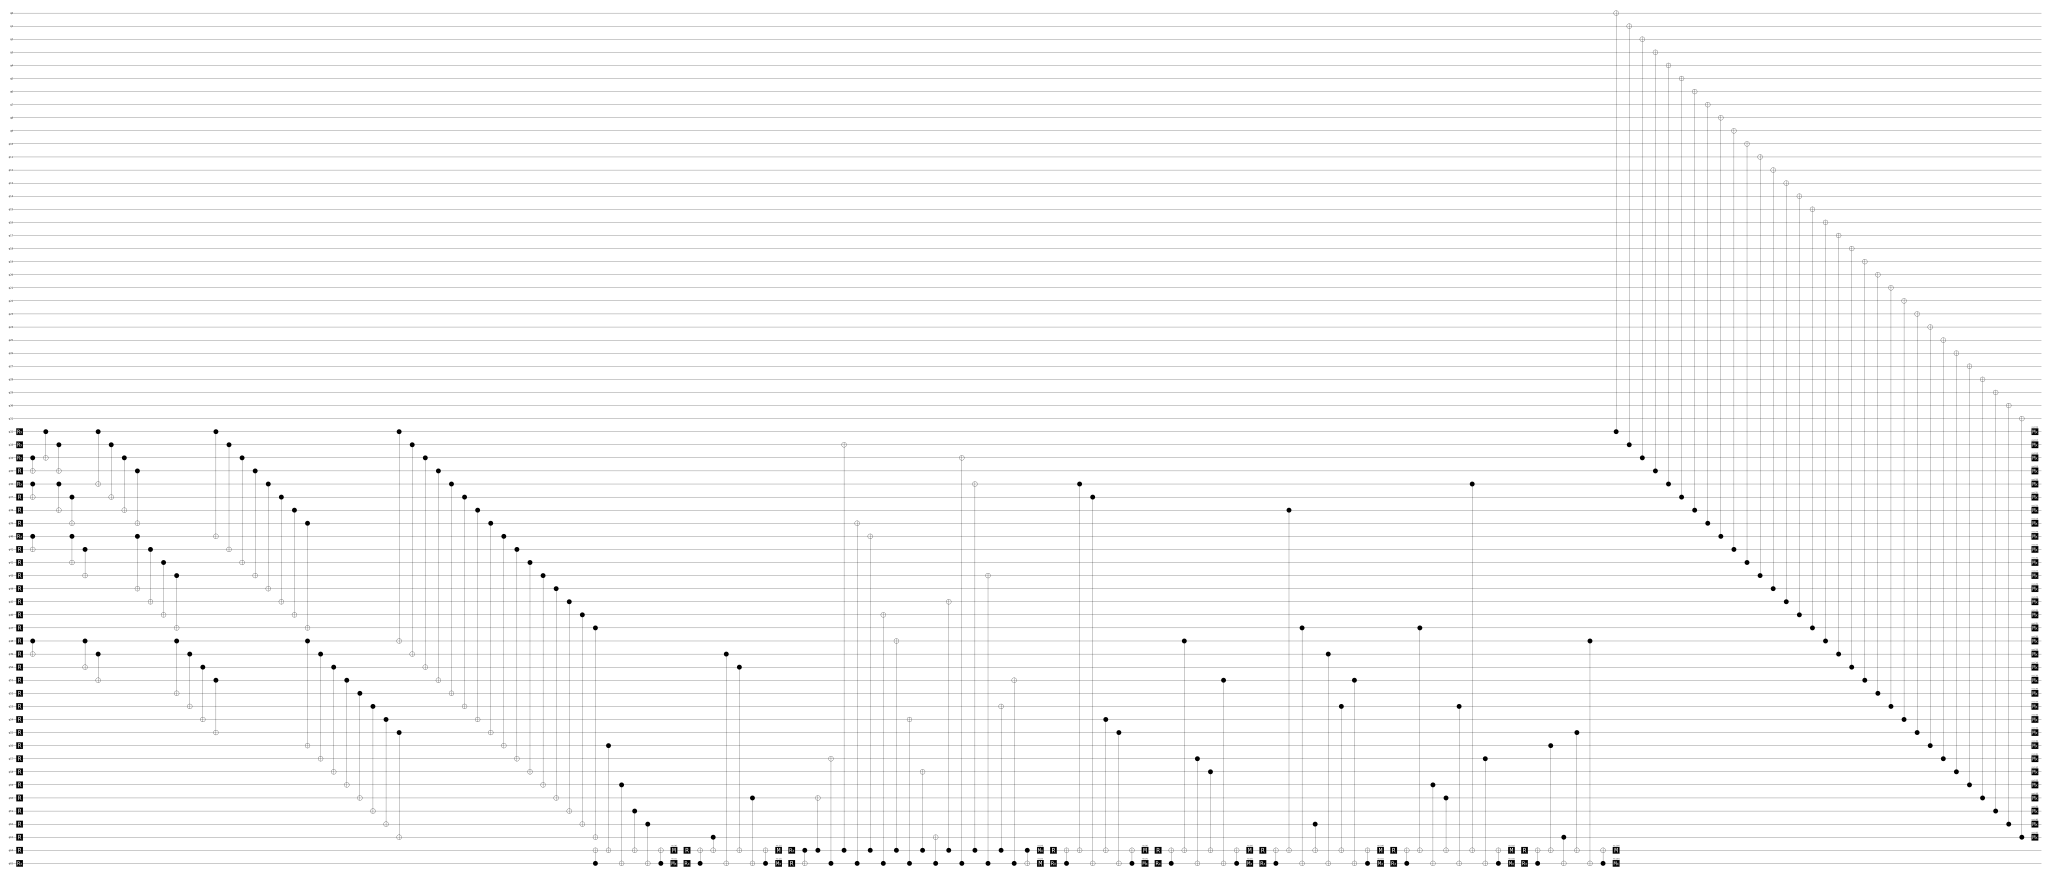

In [14]:
circuit = load_state_prep_circuit(circ_dir, circ_path)
se = steane_se_from_stim_state_prep(circuit, se_basis="Z", n=code.n)

print("Depth", get_circuit_depth(se))
print("Number of ancilla qubits necessary:", se.num_qubits - code.n)
se.diagram('timeline-svg')

In [10]:
samples = (perfect_state + se).compile_sampler().sample(10)
samples = samples[:,code.H_z.shape[0]:]
print(samples[:,:-code.n].astype(int))
print(samples[:,-code.n:] @ code.H_z.T % 2)

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
[[0 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 0 0 0 0]]


Depth 21
Number of ancilla qubits necessary: 48
Mapping of new measurements to old measurements: {0: 16, 1: 19, 2: 25, 3: 26, 4: 28, 5: 36, 6: 21, 7: 22, 8: 0, 9: 1, 10: 2, 11: 3, 12: 23, 13: 31, 14: 33, 15: 34, 16: 40, 17: 43, 18: 45, 19: 30, 20: 39, 21: 46, 22: 17, 23: 44, 24: 24, 25: 18, 26: 47, 27: 27, 28: 14, 29: 15, 30: 29, 31: 32, 32: 42, 33: 8, 34: 9, 35: 4, 36: 5, 37: 35, 38: 6, 39: 7, 40: 10, 41: 11, 42: 20, 43: 38, 44: 37, 45: 12, 46: 13, 47: 41}


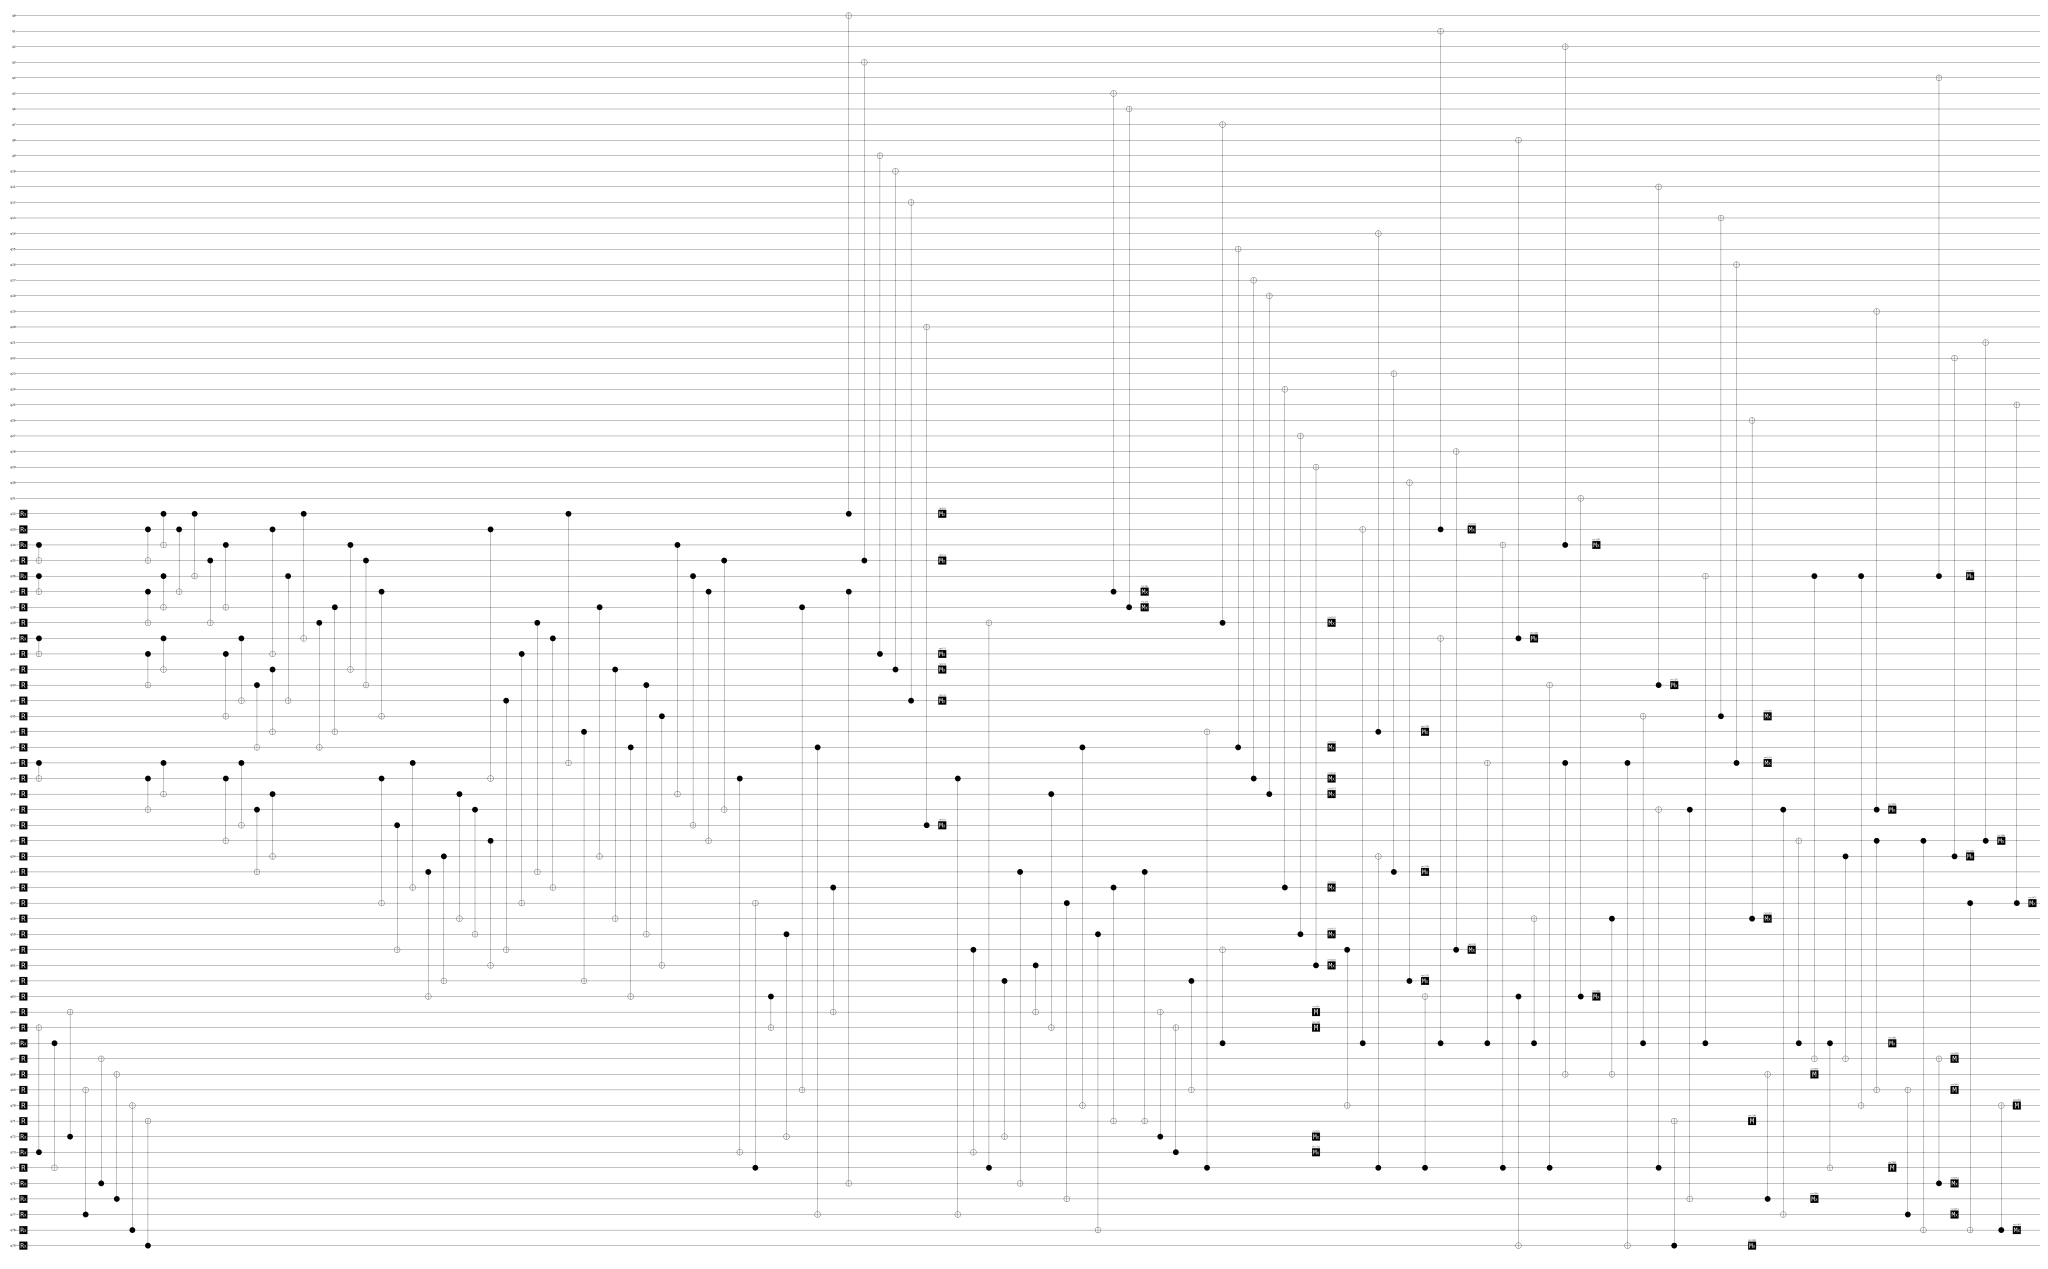

In [17]:
covered = CoveredZXGraph.from_stim(se)
covered.basic_FE_rewrites()
# optimised = covered.greedy_best_first_boundary_bends(
    # cost_func=metric_hardware_qubits_exact(AggressiveDepthAwareStrategy),
    # cost_func=metric_spacetime_volume_exact(VolumeOptimizingReuseStrategy),
    # max_evaluations=10
# )
optimised = covered.shallow_copy()
optimised.optimize_path_fronts()
new_circuit, measurement_map = optimised.extract_circuit_with_measurement_map()

print("Depth",get_circuit_depth(new_circuit))

print("Number of ancilla qubits necessary:", new_circuit.num_qubits - code.n)
print("Mapping of new measurements to old measurements:", measurement_map)
new_circuit.diagram('timeline-svg')

In [12]:
samples = (perfect_state + new_circuit).compile_sampler().sample(10)
samples = samples[:,code.H_z.shape[0]:]

num_measurements = get_num_measurements(se)
flag_indices = [k for k, v in measurement_map.items() if v < num_measurements - code.n]
flags = samples[:,flag_indices].astype(int)

print("Flags:", flags, sep="\n", end="\n\n")

syndrome_indices = {k: v - (num_measurements - code.n) for k, v in measurement_map.items() if v >= num_measurements - code.n}
effective_H = code.H_z[:,list(syndrome_indices.values())]
raw_syndrome_measurements = samples[:,list(syndrome_indices.keys())]
syndromes = raw_syndrome_measurements @ effective_H.T % 2

print("Syndromes:", syndromes, sep="\n")

Flags:
[[0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

Syndromes:
[[0 1 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 1 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 0 0 0 0]]


Number of ancilla qubits necessary: 31
Mapping of new measurements to old measurements: {0: 19, 1: 43, 2: 25, 3: 21, 4: 23, 5: 30, 6: 46, 7: 31, 8: 33, 9: 18, 10: 27, 11: 3, 12: 36, 13: 2, 14: 34, 15: 17, 16: 44, 17: 16, 18: 45, 19: 24, 20: 0, 21: 1, 22: 29, 23: 5, 24: 4, 25: 38, 26: 42, 27: 20, 28: 6, 29: 7, 30: 8, 31: 9, 32: 41, 33: 37, 34: 35, 35: 10, 36: 11, 37: 12, 38: 13, 39: 40, 40: 39, 41: 47, 42: 32, 43: 14, 44: 15}


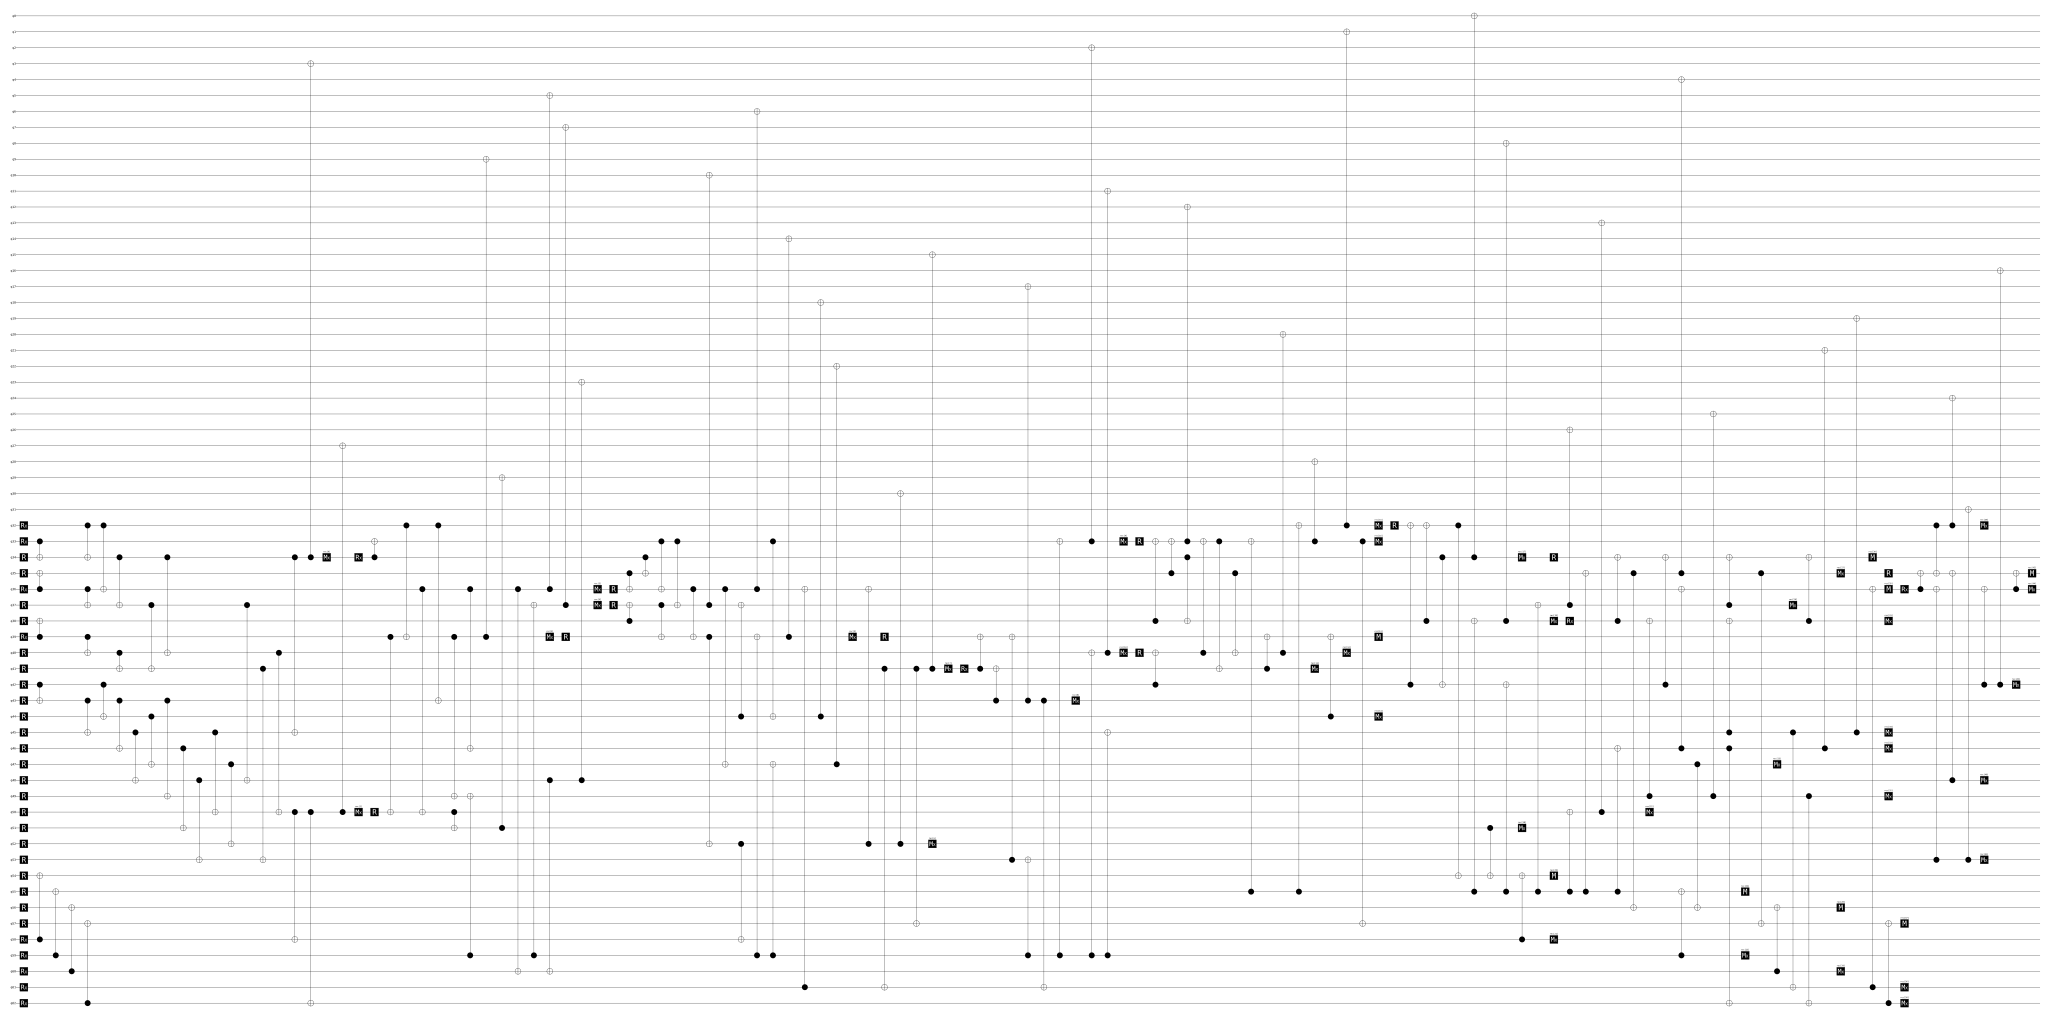

In [9]:
dag = build_circuit_dag(optimised)

mod_dag, logical_to_physical, total_hw = inject_qubit_reuse(dag, code.n, AggressiveDepthAwareStrategy())
compressed_dag = apply_logical_qubit_merge_and_compress(mod_dag, code.n)
final_circ, final_meas_map = dag_to_circuit(compressed_dag)

print("Number of ancilla qubits necessary:", final_circ.num_qubits - code.n)
print("Mapping of new measurements to old measurements:", final_meas_map)
final_circ.diagram('timeline-svg')

In [12]:
samples = (perfect_state + final_circ).compile_sampler().sample(10)
samples = samples[:,code.H_z.shape[0]:]

num_measurements = get_num_measurements(se)
flag_indices = [k for k, v in final_meas_map.items() if v < num_measurements - code.n]
flags = samples[:,flag_indices].astype(int)

print("Flags:", flags, sep="\n", end="\n\n")

syndrome_indices = {k: v - (num_measurements - code.n) for k, v in final_meas_map.items() if v >= num_measurements - code.n}
effective_H = code.H_z[:,list(syndrome_indices.values())]
raw_syndrome_measurements = samples[:,list(syndrome_indices.keys())]
syndromes = raw_syndrome_measurements @ effective_H.T % 2

print("Syndromes:", syndromes, sep="\n")

Flags:
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

Syndromes:
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 1 0 0 0 0]
 [0 1 0 0 0 0]
 [0 1 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]


In [13]:
from spiderwarp.stim_utils import get_circuit_depth, get_spacetime_volume

print(get_circuit_depth(se), get_spacetime_volume(se))
print(get_circuit_depth(final_circ), get_spacetime_volume(final_circ))

60 3960
65 4095
